In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:.2f}'.format # Para mostrar hasta 2 decimales
# %matplotlib inline

archivo = "Trabajo_Almacenamiento_Eléctrico_python.xlsx"

# Leemos las hojas que tenemos
print(pd.ExcelFile(archivo).sheet_names)

['Power instaled', 'Potencia instalada', 'Generation 2023', 'Generation 2030 Renovable']


En este Excel tenemos varias hojas.
La hoja "Power Isntaled" es la dada por el enunciado de ejemplo la cual modificamos para tener los datos en tablas que ponemos en la hoja "Potencia Instalada", dónde se calcula la proporcionalidad de potencia instalada que tenemos a lo largo del año para extrapolar la producción al año 2030.

In [89]:
df_Pins = pd.read_excel(archivo, sheet_name="Potencia instalada", header=0)

# 2. TABLA 1: Evolución mensual 2023
# Datos de la fila 1 a la 11, columnas de la 0 a la 12
df_potencia_2023 = df_Pins.iloc[1:12, 0:13].copy()
df_potencia_2023.columns = df_Pins.iloc[0, 0:13].values
df_potencia_2023.reset_index(drop=True, inplace=True)


# 3. TABLA 2: PNIEC Peninsular 2030
# Datos de la fila 1 a la 11, columnas 14 y 15
df_pniec_2030 = df_Pins.iloc[1:12, 14:16].copy()
df_pniec_2030.columns = ["Energía", "Potencia_MW"]
df_pniec_2030.reset_index(drop=True, inplace=True)


# 4. TABLA 3: Proporcionalidades
# Las cabeceras están en la fila 16, y los datos van de la 17 a la 27. Columnas de la 0 a la 12
df_proporcionalidad = df_Pins.iloc[17:28, 0:13].copy()
df_proporcionalidad.columns = df_Pins.iloc[16, 0:13].values
df_proporcionalidad.reset_index(drop=True, inplace=True)


# Mostramos un resumen de las 3 tablas para confirmar que están perfectas:
print("--- DATOS 2023 ---")
display(df_potencia_2023)

print("\n--- DATOS PNIEC 2030 ---")
display(df_pniec_2030)

print("\n--- PROPORCIONALIDADES ---")
display(df_proporcionalidad)

--- DATOS 2023 ---


,Energía,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
0,Nuclear,7117.29,7117.29,7117.29,7117.29,7117.29,7117.29,7117.29,7117.29,7117.29,7117.29,7117.29,7117.29
1,Fuel,7.95,7.95,7.95,7.95,7.95,7.95,7.95,7.95,7.95,7.95,7.95,7.95
2,Carbón,3223.16,3223.16,3223.16,3223.16,3223.16,3223.16,3223.16,3223.16,3223.16,3223.16,3223.16,3223.16
3,Ciclos,24561.85,24561.85,24561.85,24561.85,24561.85,24561.85,24561.85,24561.85,24561.85,24561.85,24561.85,24561.85
4,Cogeneración y otros,5976.98,5976.98,5976.98,5976.98,5976.68,5976.68,5976.68,5976.68,5976.68,5968.91,5968.91,5968.91
5,Hidráulica,20424.78,20424.78,20427.21,20427.21,20427.21,20427.21,20427.21,20427.21,20427.21,20427.21,20427.21,20427.21
6,Eólica,29596.04,29670.49,29720.39,29731.39,29768.39,29833.69,29854.31,29900.71,29923.91,30000.71,30095.11,30100.11
7,Solar FV,19761.00,20184.67,20719.38,21076.89,21358.35,22314.49,22530.63,23007.78,23358.66,23881.77,24358.21,24561.74
8,Termosolar,2304.01,2304.01,2304.01,2304.01,2304.01,2304.01,2304.01,2304.01,2304.01,2304.01,2304.01,2304.01
9,Resto RES,1218.98,1218.98,1218.98,1218.98,1218.98,1218.98,1218.98,1218.98,1218.98,1218.98,1218.98,1218.98



--- DATOS PNIEC 2030 ---


,Energía,Potencia_MW
0,Nuclear,3041
1,Fuel,0
2,Carbón,0
3,Ciclos,24498
4,Cogeneración y otros,4071
5,Hidráulica,14561
6,Eólica,60312
7,Solar FV,72751
8,Termosolar,4800
9,Resto RES,1964



--- PROPORCIONALIDADES ---


,Energía,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
0,Nuclear,0.43,0.43,0.43,0.43,0.43,0.43,0.43,0.43,0.43,0.43,0.43,0.43
1,Fuel,0,0,0,0,0,0,0,0,0,0,0,0
2,Carbón,0,0,0,0,0,0,0,0,0,0,0,0
3,Ciclos,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
4,Cogeneración y otros,0.68,0.68,0.68,0.68,0.68,0.68,0.68,0.68,0.68,0.68,0.68,0.68
5,Hidráulica,0.71,0.71,0.71,0.71,0.71,0.71,0.71,0.71,0.71,0.71,0.71,0.71
6,Eólica,2.04,2.03,2.03,2.03,2.03,2.02,2.02,2.02,2.02,2.01,2.00,2.00
7,Solar FV,3.68,3.60,3.51,3.45,3.41,3.26,3.23,3.16,3.11,3.05,2.99,2.96
8,Termosolar,2.08,2.08,2.08,2.08,2.08,2.08,2.08,2.08,2.08,2.08,2.08,2.08
9,Resto RES,1.61,1.61,1.61,1.61,1.61,1.61,1.61,1.61,1.61,1.61,1.61,1.61


In [90]:
df_2023 = pd.read_excel(archivo, sheet_name="Generation 2023", header=3)

df_2023 = df_2023.iloc[:105120].copy()
df_2023.head(5) # Mostramos 5 filas para comprobar que esté funcionando

,MES,Fecha,Hour,Nuclear,Fuel,Coal,CCG,Co-generation and waste,Hydo,Wind,PV,Solar Thermal,Renewable thermal,Total,Renovable,NO Renovable,%Renovable
0,Enero,2023-01-01,00:00:00,6465.00,0,251.00,2296.00,929.00,552.00,7054.00,20.00,0.00,253.00,17820.00,7626.00,10194.00,0.43
1,Enero,2023-01-01,00:05:00,6468.00,0,276.00,2278.00,936.00,229.00,6702.00,20.00,0.00,236.00,17145.00,6951.00,10194.00,0.41
2,Enero,2023-01-01,00:10:00,6470.00,0,289.00,2341.00,935.00,204.00,6295.00,20.00,0.00,236.00,16790.00,6519.00,10271.00,0.39
3,Enero,2023-01-01,00:15:00,6467.00,0,292.00,2286.00,945.00,168.00,6230.00,20.00,0.00,236.00,16644.00,6418.00,10226.00,0.39
4,Enero,2023-01-01,00:20:00,6465.00,0,301.00,2227.00,936.00,145.00,6129.00,20.00,0.00,236.00,16459.00,6294.00,10165.00,0.38


Con la demanda del 2023 y la tabla previa de proporcionalidad calculamos la Generación del 2030. (Este cálculo se realizó en Excel en la hoja "Generation 2030 Renovable")

In [91]:
df_2030r = pd.read_excel(archivo, sheet_name="Generation 2030 Renovable", header=3)

df_2030r = df_2030r.iloc[:105120].copy()
df_2030r.head(5) # Mostramos 5 filas para comprobar que esté funcionando

,MES,Fecha,Hour,Nuclear,Fuel,Coal,CCG,Co-generation and waste,Hydo,Wind,PV,Solar Thermal,Renewable thermal,Total,Renovable,NO Renovable,%Renovable
0,Enero,2023-01-01,00:00:00,2762.30,0.00,0.00,2290.03,632.75,393.53,14374.92,73.63,0.00,407.63,20934.79,15249.71,5685.08,0.73
1,Enero,2023-01-01,00:05:00,2763.58,0.00,0.00,2272.08,637.52,163.26,13657.60,73.63,0.00,380.24,19947.91,14274.73,5673.18,0.72
2,Enero,2023-01-01,00:10:00,2764.43,0.00,0.00,2334.91,636.84,145.43,12828.20,73.63,0.00,380.24,19163.70,13427.51,5736.19,0.70
3,Enero,2023-01-01,00:15:00,2763.15,0.00,0.00,2280.06,643.65,119.77,12695.74,73.63,0.00,380.24,18956.24,13269.38,5686.86,0.70
4,Enero,2023-01-01,00:20:00,2762.30,0.00,0.00,2221.21,637.52,103.37,12489.92,73.63,0.00,380.24,18668.19,13047.16,5621.03,0.70


En el enunciado mencionan que consideremos que la demanda aumenta un 16%, de manera que calculamos el consumo en 2030 en base a la demanda del 2023.

In [92]:
Aumento_consumo= 0.16
df_2023["Consumo_2030"] = df_2023["Total"] * (1 + Aumento_consumo)
df_2023[["Total", "Consumo_2030"]].head(5)

,Total,Consumo_2030
0,17820.00,20671.20
1,17145.00,19888.20
2,16790.00,19476.40
3,16644.00,19307.04
4,16459.00,19092.44


# Renovable

Lo primero a analizar es la posibilidad de utilizar sólo energía renovable, demanera que se considera la posibilidad de utilizar almacenamiento. Para ellos calculamos el balance de energía según necesidad o excedente de manera que se pueda utilizar estos excedenetes en momento s de alta demanda.

In [93]:
esc_r = pd.DataFrame({
    "Fecha": df_2030r["Fecha"],
    "Hour": df_2030r["Hour"],
    "Consumo": df_2023["Consumo_2030"],
    "Renovable": df_2030r["Renovable"] })

In [94]:
esc_r["Balance"] = esc_r["Consumo"] - esc_r["Renovable"]

# positivo = falta energía
# negativo = excedente

esc_r.head(5)

,Fecha,Hour,Consumo,Renovable,Balance
0,2023-01-01,00:00:00,20671.20,15249.71,5421.49
1,2023-01-01,00:05:00,19888.20,14274.73,5613.47
2,2023-01-01,00:10:00,19476.40,13427.51,6048.89
3,2023-01-01,00:15:00,19307.04,13269.38,6037.66
4,2023-01-01,00:20:00,19092.44,13047.16,6045.28


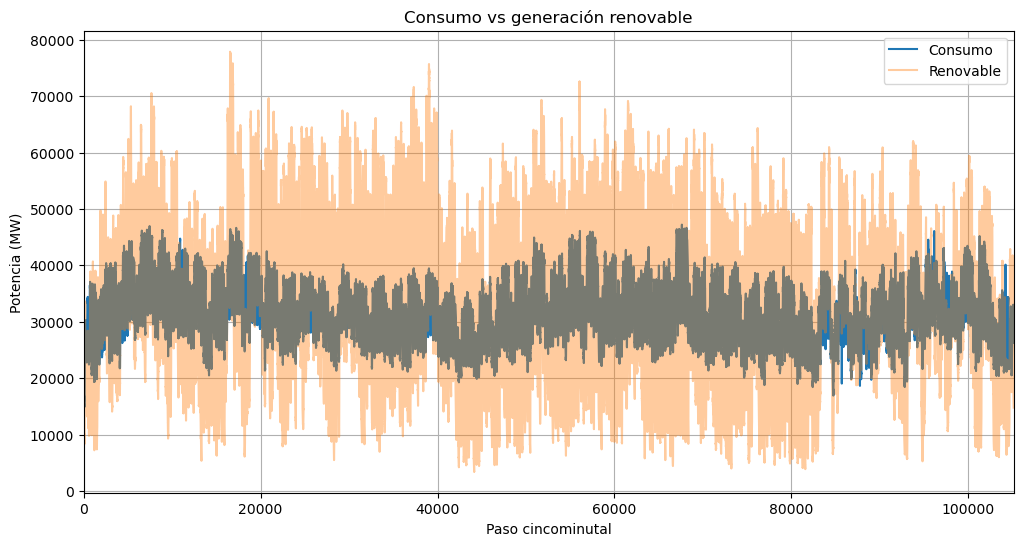

In [95]:
plt.figure(figsize=(12,6))

plt.plot(esc_r["Consumo"], label="Consumo", alpha=1)
plt.plot(esc_r["Renovable"], label="Renovable", alpha=0.4)

plt.xlabel("Paso cincominutal")
plt.ylabel("Potencia (MW)")

plt.title("Consumo vs generación renovable")
plt.xlim(0,105120)
plt.legend()
plt.grid(True)

A continuación, se busca el almacenamiento mínimo para cubrir la demanda energética. Se analizará de manera que el almacenamiento mínimo sea el 10% del máximo, además de buscar una constante base de la que partir a principio de año.

In [96]:
def optimizar_almacenamiento_minimo(df, col_gen, col_cons = "Consumo", frac_min = 0.1):

    out = df.copy()

    delta = out[col_gen] - out[col_cons]

    C = delta.cumsum()

    Cmin = C.min()
    Cmax = C.max()

    R = Cmax - Cmin

    S_max = R / (1 - frac_min)

    S_min = frac_min * S_max

    S0 = S_min - Cmin

    almacenamiento = S0 + C

    out["Delta"] = delta
    out["Acumulado"] = C
    out["Almacenamiento_optimo"] = almacenamiento

    return out, S_max, S_min, S0

In [97]:
esc_r_opt, Smax, Smin, S0 = optimizar_almacenamiento_minimo( esc_r, col_gen = "Renovable", col_cons = "Consumo", frac_min = 0.1 )

print(f"Capacidad total almacenamiento Smax: {round(Smax, 2)} (MW) -> {round(Smax / 12, 2)} MWh")
print(f"Capacidad mínima Smin: {round(Smin, 2)} (MW) -> {round(Smin / 12, 2)} MWh")
print(f"Capacidad útil: {round(Smax - Smin, 2)} (MW) -> {round((Smax - Smin) / 12, 2)} MWh")

# Mostramos las 5 primeras filas redondeadas a 2 decimales
display(esc_r_opt.head(5))

Capacidad total almacenamiento Smax: 151621221.91 (MW) -> 12635101.83 MWh
Capacidad mínima Smin: 15162122.19 (MW) -> 1263510.18 MWh
Capacidad útil: 136459099.72 (MW) -> 11371591.64 MWh


,Fecha,Hour,Consumo,Renovable,Balance,Delta,Acumulado,Almacenamiento_optimo
0,2023-01-01,00:00:00,20671.20,15249.71,5421.49,-5421.49,-5421.49,124977586.62
1,2023-01-01,00:05:00,19888.20,14274.73,5613.47,-5613.47,-11034.96,124971973.16
2,2023-01-01,00:10:00,19476.40,13427.51,6048.89,-6048.89,-17083.85,124965924.26
3,2023-01-01,00:15:00,19307.04,13269.38,6037.66,-6037.66,-23121.51,124959886.61
4,2023-01-01,00:20:00,19092.44,13047.16,6045.28,-6045.28,-29166.78,124953841.33


In [98]:
delta = esc_r_opt["Delta"]

P_carga = delta.clip(lower=0).max() # Eliminamos los menores de 0
P_descarga = (-delta.clip(upper=0)).max()

print(f"Potencia de carga: {round(P_carga, 2)} (MW) -> {round((P_carga) / 12, 2)} MWh")
print(f"Potencia de carga: {round(P_descarga, 2)} (MW) -> {round((P_descarga) / 12, 2)} MWh")

Potencia de carga: 36446.87 (MW) -> 3037.24 MWh
Potencia de carga: 27673.06 (MW) -> 2306.09 MWh


In [99]:
esc_r_opt["Almacenamiento_util"] = esc_r_opt["Almacenamiento_optimo"] - Smin
esc_r_opt.head(5)

,Fecha,Hour,Consumo,Renovable,Balance,Delta,Acumulado,Almacenamiento_optimo,Almacenamiento_util
0,2023-01-01,00:00:00,20671.20,15249.71,5421.49,-5421.49,-5421.49,124977586.62,109815464.43
1,2023-01-01,00:05:00,19888.20,14274.73,5613.47,-5613.47,-11034.96,124971973.16,109809850.96
2,2023-01-01,00:10:00,19476.40,13427.51,6048.89,-6048.89,-17083.85,124965924.26,109803802.07
3,2023-01-01,00:15:00,19307.04,13269.38,6037.66,-6037.66,-23121.51,124959886.61,109797764.42
4,2023-01-01,00:20:00,19092.44,13047.16,6045.28,-6045.28,-29166.78,124953841.33,109791719.14


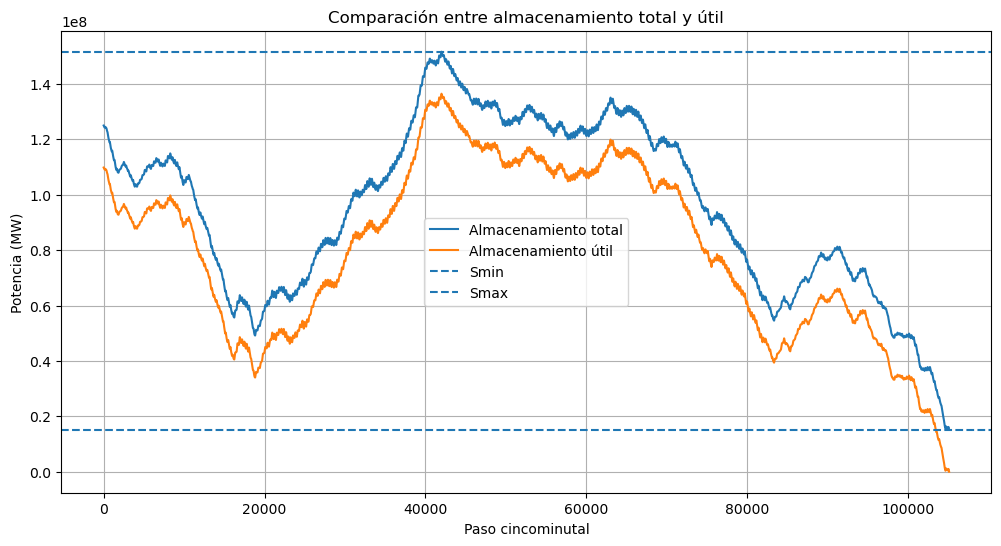

In [100]:
plt.figure(figsize=(12,6))

plt.plot(esc_r_opt["Almacenamiento_optimo"], label="Almacenamiento total")
plt.plot(esc_r_opt["Almacenamiento_util"], label="Almacenamiento útil")

plt.axhline(Smin, linestyle="--", label="Smin")
plt.axhline(Smax, linestyle="--", label="Smax")

plt.xlabel("Paso cincominutal")
plt.ylabel("Potencia (MW)")
plt.title("Comparación entre almacenamiento total y útil")

plt.legend()
plt.grid(True)
plt.show()

# Renovable + CCG

En este escenario, en vez de aprovechar toda la energía renovable se intentará minimizar el almacenamiento de manera

In [101]:
esc_r_ccg = pd.DataFrame({
    "Fecha": df_2030r["Fecha"],
    "Hour": df_2030r["Hour"],
    "Consumo": df_2023["Consumo_2030"],
    "Renovable": df_2030r["Renovable"]})

# CCG cubre sólo lo que no cubre la renovable
esc_r_ccg["CCG_necesario"] = np.maximum(esc_r_ccg["Consumo"] - esc_r_ccg["Renovable"], 0)

# Exceso renovable perdido si no hay almacenamiento
esc_r_ccg["Exceso_R_sin_almacenamiento"] = np.maximum(esc_r_ccg["Renovable"] - esc_r_ccg["Consumo"], 0) # Los meses de verano

# Generación total del sistema en este caso
esc_r_ccg["Generacion_total"] = esc_r_ccg["Renovable"] + esc_r_ccg["CCG_necesario"]

esc_r_ccg.head(5)

,Fecha,Hour,Consumo,Renovable,CCG_necesario,Exceso_R_sin_almacenamiento,Generacion_total
0,2023-01-01,00:00:00,20671.20,15249.71,5421.49,0.00,20671.20
1,2023-01-01,00:05:00,19888.20,14274.73,5613.47,0.00,19888.20
2,2023-01-01,00:10:00,19476.40,13427.51,6048.89,0.00,19476.40
3,2023-01-01,00:15:00,19307.04,13269.38,6037.66,0.00,19307.04
4,2023-01-01,00:20:00,19092.44,13047.16,6045.28,0.00,19092.44


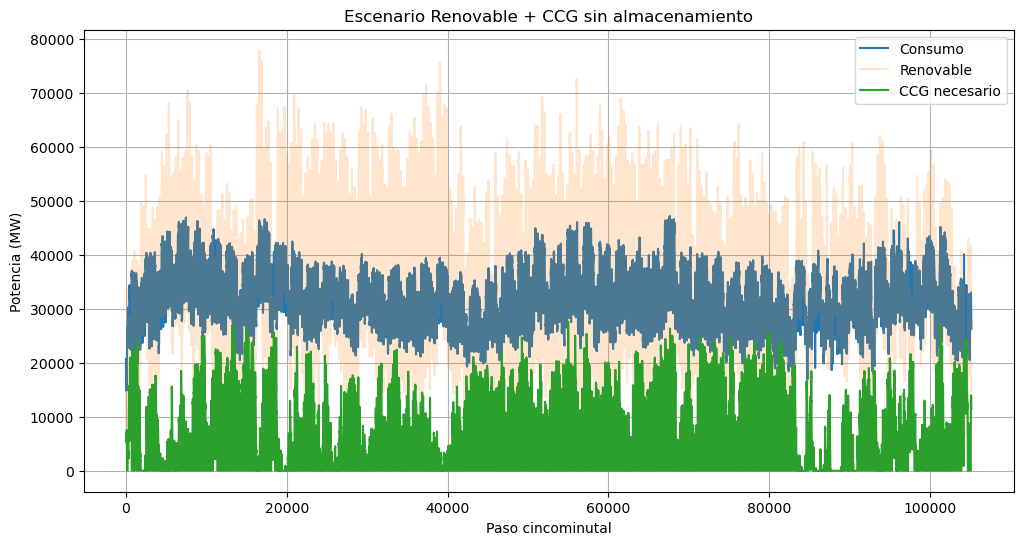

In [102]:
plt.figure(figsize=(12,6))

plt.plot(esc_r_ccg["Consumo"], label="Consumo")
plt.plot(esc_r_ccg["Renovable"], label="Renovable", alpha=0.2)
plt.plot(esc_r_ccg["CCG_necesario"], label="CCG necesario")

plt.xlabel("Paso cincominutal")
plt.ylabel("Potencia (MW)")
plt.title("Escenario Renovable + CCG sin almacenamiento")

plt.legend()
plt.grid(True)
plt.show()

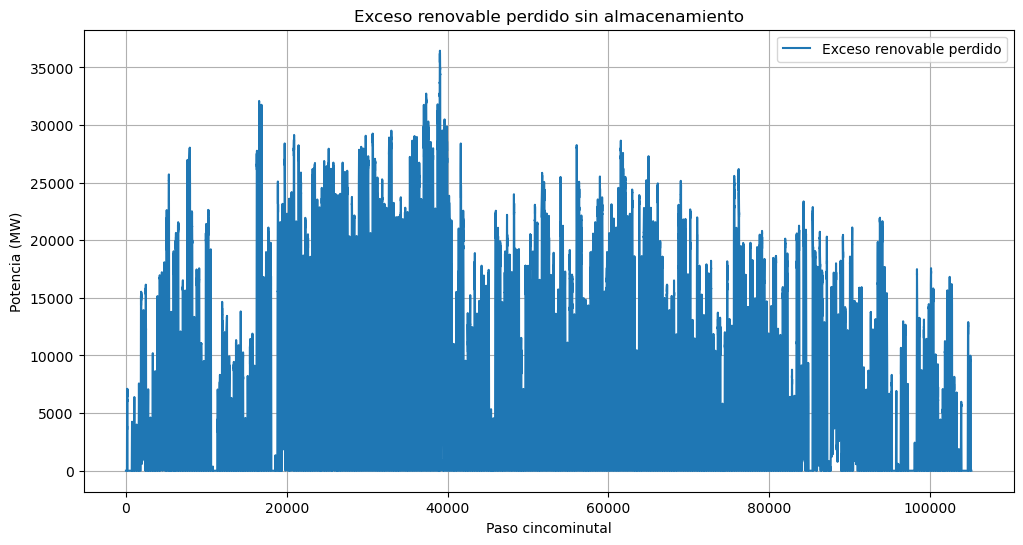

In [103]:
plt.figure(figsize=(12,6))

plt.plot(esc_r_ccg["Exceso_R_sin_almacenamiento"], label="Exceso renovable perdido")

plt.xlabel("Paso cincominutal")
plt.ylabel("Potencia (MW)")
plt.title("Exceso renovable perdido sin almacenamiento")

plt.legend()
plt.grid(True)
plt.show()

In [104]:
ER_perdida_total = esc_r_ccg["Exceso_R_sin_almacenamiento"].sum()
energia_total_ccg = esc_r_ccg["CCG_necesario"].sum()

print(f"ER perdida sin almacenamiento: {round(ER_perdida_total, 2)} (MW) -> {round((ER_perdida_total) / 12, 2)} MWh")
print(f"Energía total producida por CCG: {round(energia_total_ccg, 2)} (MW) -> {round((energia_total_ccg) / 12, 2)} MWh")

ER perdida sin almacenamiento: 568430464.06 (MW) -> 47369205.34 MWh
Energía total producida por CCG: 678251349.99 (MW) -> 56520945.83 MWh


In [105]:
# Leemos específicamente la celda P6 de la hoja correcta dónde está la potencia instalada del CCG
potencia_ccg = pd.read_excel(
    archivo,
    sheet_name="Potencia instalada", # <-- ¡Aquí está el cambio!
    usecols="P",                     # Solo lee la columna P
    skiprows=5,                      # Se salta las 5 primeras filas (para llegar a la 6)
    nrows=1,                         # Solo lee 1 fila
    header=None                      # No busca nombres de columnas
).iloc[0, 0]                         # Extrae el número directamente

print("Potencia CCG según PNIEC (MWh):", potencia_ccg)

# Y luego tu cálculo de horas (¡con la energía dividida por 12!)
horas_equivalentes_R = energia_total_ccg/ 12 / potencia_ccg 
print(f"Horas equivalentes de funcionamiento CCG: {round(horas_equivalentes_R, 2)}")

Potencia CCG según PNIEC (MWh): 24498
Horas equivalentes de funcionamiento CCG: 2307.17


Si se quiere evitar el curtailment de las energías renovables, obtener el almacenamiento necesario y obtener las horas equivalentes de funcionamiento de las centrales de CCG

In [106]:
def almacenamiento_minimo_sin_curtailment_con_reserva(df, col_gen="Renovable", col_cons="Consumo", frac_min=0.1):
    """
    Dimensiona el almacenamiento mínimo para evitar curtailment renovable
    usando CCG para el déficit, respetando un mínimo técnico (ej. 10%).

    - Carga cuando gen > cons (para evitar curtailment)
    - Descarga cuando gen < cons (hasta el límite de la capacidad útil)
    - Si se agota la capacidad útil, entra CCG
    """

    out = df.copy()

    delta = out[col_gen] - out[col_cons]  # excedente positivo, déficit negativo
    n = len(delta)

    flujo = np.zeros(n)
    almacen_util = np.zeros(n)
    ccg = np.zeros(n)

    s_util = 0
    s_util_max = 0

    for i in range(n):
        d = delta.iloc[i]

        if d > 0:
            # cargar almacenamiento (guardamos todo el excedente)
            s_util += d
            flujo[i] = d
        else:
            # descargar almacenamiento (solo hasta que s_util llegue a 0)
            descarga = min(-d, s_util)
            s_util -= descarga
            flujo[i] = -descarga

            # lo que falte lo cubre el CCG
            ccg[i] = (-d) - descarga

        almacen_util[i] = s_util
        
        # Guardamos el pico máximo de capacidad útil que hemos necesitado
        s_util_max = max(s_util_max, s_util)

    # === CÁLCULOS FINALES CON LA RESERVA ===
    # Si la capacidad útil es el 90% (1 - frac_min), el Smax total es:
    Smax = s_util_max / (1 - frac_min)
    
    # El mínimo técnico es ese % del Smax
    Smin = frac_min * Smax

    out["Delta"] = delta
    out["Flujo_almacenamiento"] = flujo
    out["Almacenamiento_util"] = almacen_util
    # La energía total almacenada es la útil más el colchón del mínimo técnico
    out["Almacenamiento_total"] = almacen_util + Smin
    out["CCG"] = ccg

    return out, Smax, Smin

In [107]:
esc_r_ccg_opt, Smax_ccg, Smin_ccg = almacenamiento_minimo_sin_curtailment_con_reserva(
    esc_r_ccg,
    col_gen="Renovable",
    col_cons="Consumo",
    frac_min=0.1
)

print(f"Capacidad total necesaria (Smax): {round(Smax_ccg / 12, 2)} MWh")
print(f"Mínimo técnico (Smin): {round(Smin_ccg / 12, 2)} MWh")
print(f"Capacidad útil: {round((Smax_ccg - Smin_ccg) / 12, 2)} MWh")

Capacidad total necesaria (Smax): 9486863.03 MWh
Mínimo técnico (Smin): 948686.3 MWh
Capacidad útil: 8538176.73 MWh


In [108]:
exceso = np.maximum(esc_r_ccg["Renovable"] - esc_r_ccg["Consumo"], 0)

excedente_total_MWh = exceso.sum() / 12
almacenamiento_max_MWh = esc_r_ccg_opt["Almacenamiento_total"].max() / 12

print(f"Excedente renovable total (MWh): {round(excedente_total_MWh, 2)}")
print(f"Almacenamiento máximo utilizado (MWh): {round(almacenamiento_max_MWh, 2)}")

Excedente renovable total (MWh): 47369205.34
Almacenamiento máximo utilizado (MWh): 9486863.03


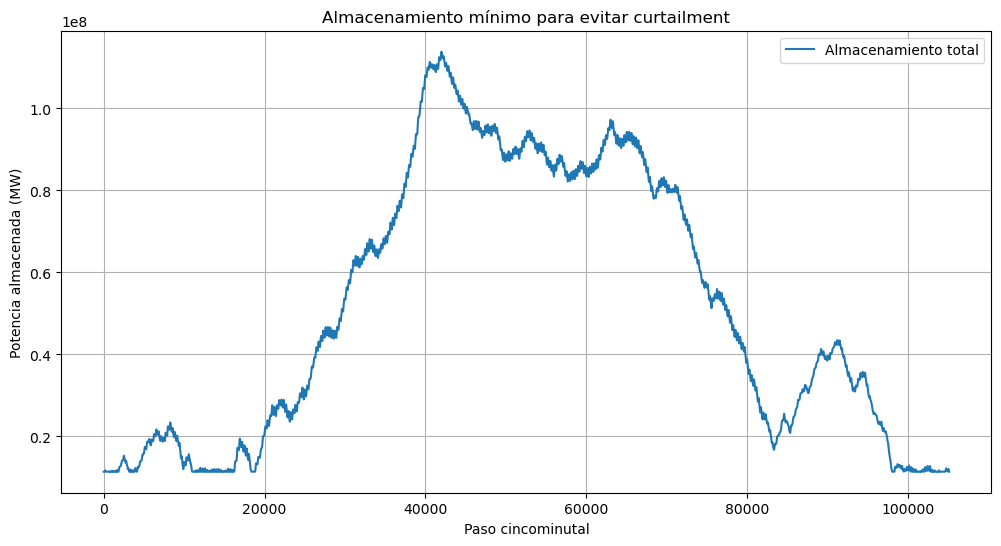

In [109]:
plt.figure(figsize=(12,6))

plt.plot(esc_r_ccg_opt["Almacenamiento_total"], label="Almacenamiento total")
plt.xlabel("Paso cincominutal")
plt.ylabel("Potencia almacenada (MW)")
plt.title("Almacenamiento mínimo para evitar curtailment")

plt.legend()
plt.grid(True)
plt.show()

In [110]:
energia_ccg_MWh = esc_r_ccg_opt["CCG"].sum() * (5/60)

print("Energía anual CCG (MWh):", energia_ccg_MWh)

horas_equivalentes_CCG = energia_ccg_MWh / potencia_ccg 
print("Horas equivalentes de funcionamiento CCG:", horas_equivalentes_CCG)

Energía anual CCG (MWh): 9151740.493540488
Horas equivalentes de funcionamiento CCG: 373.57092389339897


### Si se dispone de un máximo de 50 GWh:
• ¿Se satisface el 100% de la demanda?
• ¿Cuánta ER se pierde?
• Obtener las horas equivalentes de funcionamiento de las centrales de CCG

In [111]:
def simulacion_limite_bateria_y_ccg(df, col_gen="Renovable", col_cons="Consumo", Smax_MWh=50000, frac_min=0.1, Pmax_ccg_MW=24498):
    
    out = df.copy()
    delta = out[col_gen] - out[col_cons]
    n = len(delta)

    Smax = Smax_MWh * 12
    Smin = frac_min * Smax

    almacen_total = np.zeros(n)
    almacen_util = np.zeros(n)
    ccg = np.zeros(n)
    vertido = np.zeros(n)
    demanda_fallada = np.zeros(n) # NUEVO: Guardamos cuándo hay apagón

    s = Smin 

    for i in range(n):
        d = delta.iloc[i]

        if d > 0:
            carga = min(d, Smax - s)
            s += carga
            vertido[i] = d - carga
        else:
            descarga = min(-d, s - Smin)
            s -= descarga
            
            # Lo que no pueda cubrir la batería, se lo pedimos al CCG
            deficit_restante = (-d) - descarga
            
            # EL CAMBIO CLAVE: El CCG genera como máximo su potencia instalada
            generacion_ccg = min(deficit_restante, Pmax_ccg_MW)
            ccg[i] = generacion_ccg
            
            # Si el déficit era mayor que lo que puede dar el CCG, hay apagón
            demanda_fallada[i] = deficit_restante - generacion_ccg

        almacen_total[i] = s
        almacen_util[i] = s - Smin

    out["Almacenamiento_total"] = almacen_total
    out["Almacenamiento_util"] = almacen_util
    out["CCG"] = ccg
    out["Vertido_ER"] = vertido
    out["Demanda_No_Cubierta"] = demanda_fallada

    return out

In [112]:
# 1. Llamamos a la función con el límite de 50GWh y el límite del CCG
esc_r_ccg_50 = simulacion_limite_bateria_y_ccg(
    esc_r_ccg,
    col_gen="Renovable",
    col_cons="Consumo",
    Smax_MWh=50000,
    frac_min=0.1,
    Pmax_ccg_MW=potencia_ccg  # La variable que sacamos del Excel (24498)
)

# 2. Resultados en MWh (dividimos entre 12)
demanda_no_cubierta = esc_r_ccg_50["Demanda_No_Cubierta"].sum() / 12
ER_perdida = esc_r_ccg_50["Vertido_ER"].sum() / 12
energia_ccg_50_MWh = esc_r_ccg_50["CCG"].sum() / 12
horas_equivalentes_50 = energia_ccg_50_MWh / potencia_ccg

print(f"Demanda no cubierta (MWh): {round(demanda_no_cubierta, 2)}")
print(f"Energía renovable perdida (MWh): {round(ER_perdida, 2)}")
print(f"Energía total generada por CCG (MWh): {round(energia_ccg_50_MWh, 2)}")
print(f"Horas equivalentes CCG: {round(horas_equivalentes_50, 2)} horas")

Demanda no cubierta (MWh): 30418.46
Energía renovable perdida (MWh): 33846843.17
Energía total generada por CCG (MWh): 42968165.2
Horas equivalentes CCG: 1753.95 horas


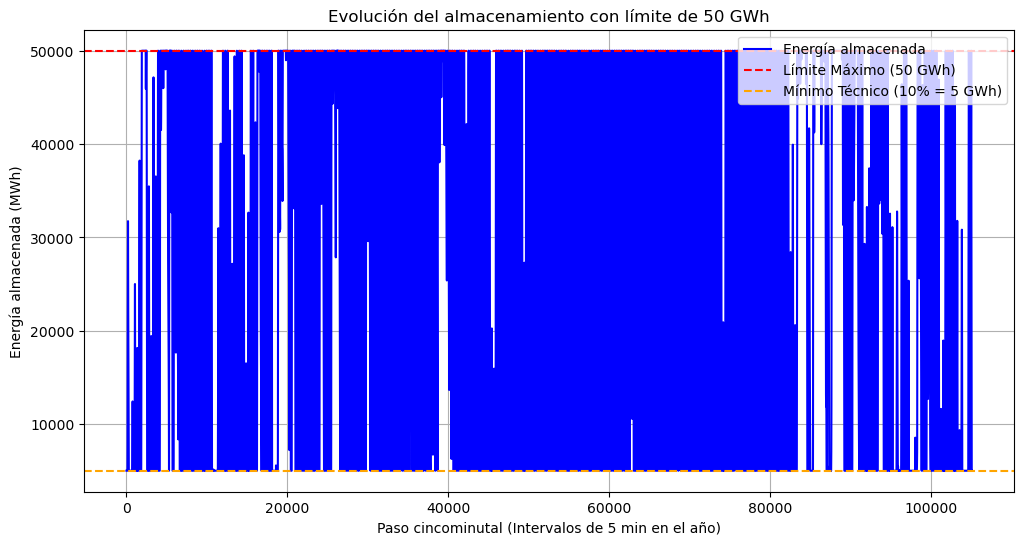

In [113]:
plt.figure(figsize=(12,6))

# Dibujamos la curva del almacenamiento total (dividida entre 12 para que sean MWh)
plt.plot(esc_r_ccg_50["Almacenamiento_total"] / 12, label="Energía almacenada", color="blue")

# Añadimos líneas horizontales para marcar los límites físicos de la batería
plt.axhline(50000, color="red", linestyle="--", label="Límite Máximo (50 GWh)")
plt.axhline(5000, color="orange", linestyle="--", label="Mínimo Técnico (10% = 5 GWh)")

plt.xlabel("Paso cincominutal (Intervalos de 5 min en el año)")
plt.ylabel("Energía almacenada (MWh)")
plt.title("Evolución del almacenamiento con límite de 50 GWh")

plt.legend(loc="upper right") # Ponemos la leyenda arriba a la derecha para que no estorbe
plt.grid(True)
plt.show()

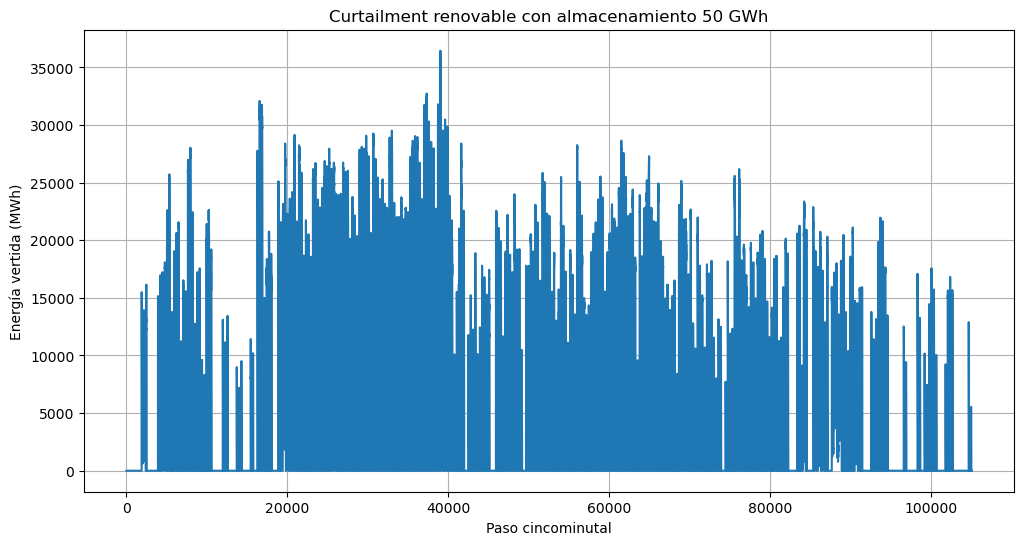

In [114]:
plt.figure(figsize=(12,6))

plt.plot(esc_r_ccg_50["Vertido_ER"])

plt.xlabel("Paso cincominutal")
plt.ylabel("Energía vertida (MWh)")
plt.title("Curtailment renovable con almacenamiento 50 GWh")

plt.grid(True)
plt.show()

# R+CCG+N

In [115]:
esc_r_n_ccg = pd.DataFrame({
    "Fecha": df_2030r["Fecha"],
    "Hour": df_2030r["Hour"],
    "Consumo": df_2023["Consumo_2030"],
    "Renovable": df_2030r["Renovable"],
    "Nuclear": df_2030r["Nuclear"]
})

# Generación base sin CCG
esc_r_n_ccg["Gen_R_N"] = esc_r_n_ccg["Renovable"] + esc_r_n_ccg["Nuclear"]

esc_r_n_ccg.head()

,Fecha,Hour,Consumo,Renovable,Nuclear,Gen_R_N
0,2023-01-01,00:00:00,20671.20,15249.71,2762.30,18012.01
1,2023-01-01,00:05:00,19888.20,14274.73,2763.58,17038.31
2,2023-01-01,00:10:00,19476.40,13427.51,2764.43,16191.94
3,2023-01-01,00:15:00,19307.04,13269.38,2763.15,16032.53
4,2023-01-01,00:20:00,19092.44,13047.16,2762.30,15809.46


### Sin almacenamiento

In [116]:
esc_r_n_ccg["CCG"] = np.maximum(
    esc_r_n_ccg["Consumo"] - esc_r_n_ccg["Gen_R_N"], 0)

esc_r_n_ccg["Vertido_ER"] = np.maximum(
    esc_r_n_ccg["Gen_R_N"] - esc_r_n_ccg["Consumo"], 0)

In [117]:
ER_perdida = esc_r_n_ccg["Vertido_ER"].sum() / 12

print("ER perdida sin almacenamiento (MWh):", ER_perdida)

ER perdida sin almacenamiento (MWh): 57387980.972496726


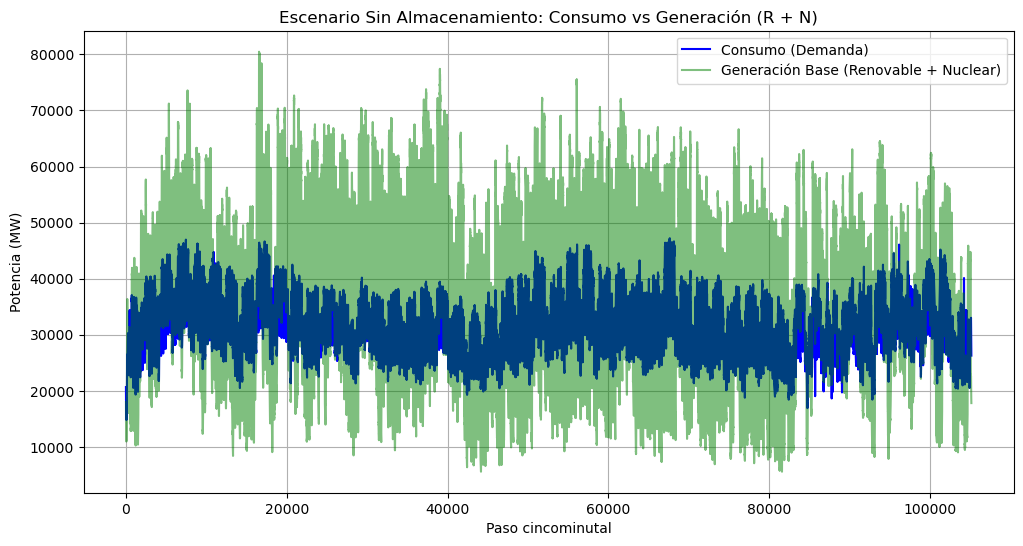

In [122]:
plt.figure(figsize=(12, 6))
plt.plot(esc_r_n_ccg["Consumo"], label="Consumo (Demanda)", color="blue", linewidth=1.5)
plt.plot(esc_r_n_ccg["Gen_R_N"], label="Generación Base (Renovable + Nuclear)", color="green", alpha=0.5)

plt.xlabel("Paso cincominutal")
plt.ylabel("Potencia (MW)")
plt.title("Escenario Sin Almacenamiento: Consumo vs Generación (R + N)")
plt.legend()
plt.grid(True)
plt.show()

### Evitar Curtailment


--- RESULTADOS PARA EVITAR CURTAILMENT ---
Capacidad total necesaria de la batería (Smax): 20303236.65 MWh
Capacidad útil de la batería: 18272912.98 MWh
Horas equivalentes de funcionamiento CCG: 73.31 horas


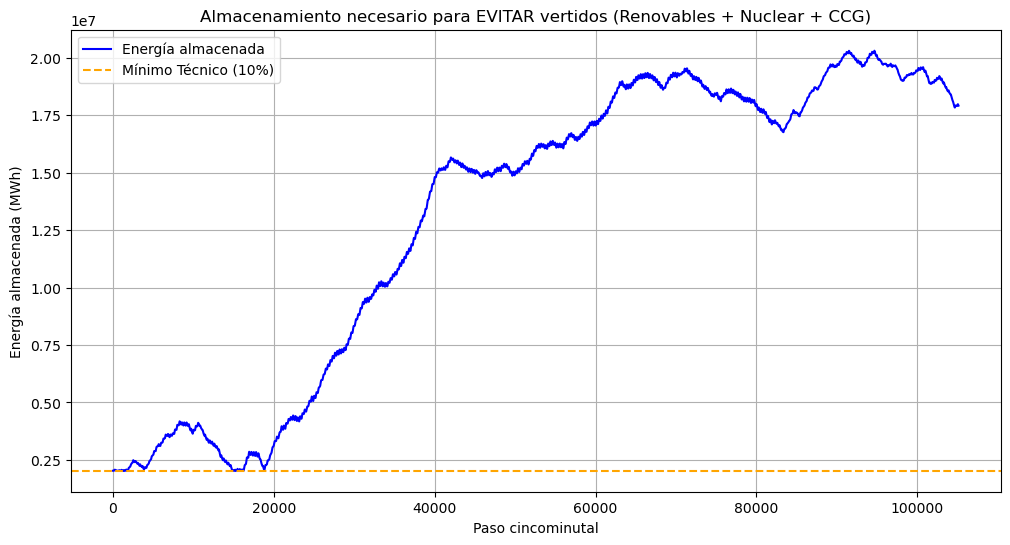

In [123]:
# --- PARTE 2: CON ALMACENAMIENTO ÓPTIMO (Evitar curtailment) ---

# Reutilizamos la función todoterreno para sacar el Smax necesario
esc_r_n_ccg_opt, Smax_RN, Smin_RN = almacenamiento_minimo_sin_curtailment_con_reserva(
    esc_r_n_ccg,            
    col_gen="Gen_R_N",      
    col_cons="Consumo",
    frac_min=0.1            
)

# Convertimos a MWh
Smax_RN_MWh = Smax_RN / 12
Smin_RN_MWh = Smin_RN / 12
energia_ccg_RN_MWh = esc_r_n_ccg_opt["CCG"].sum() / 12
horas_equivalentes_RN = energia_ccg_RN_MWh / potencia_ccg

print("\n--- RESULTADOS PARA EVITAR CURTAILMENT ---")
print(f"Capacidad total necesaria de la batería (Smax): {round(Smax_RN_MWh, 2)} MWh")
print(f"Capacidad útil de la batería: {round(Smax_RN_MWh - Smin_RN_MWh, 2)} MWh")
print(f"Horas equivalentes de funcionamiento CCG: {round(horas_equivalentes_RN, 2)} horas")

# GRÁFICA: Evolución de la batería óptima
plt.figure(figsize=(12, 6))
plt.plot(esc_r_n_ccg_opt["Almacenamiento_total"] / 12, label="Energía almacenada", color="blue")
plt.axhline(Smin_RN_MWh, color="orange", linestyle="--", label="Mínimo Técnico (10%)")

plt.xlabel("Paso cincominutal")
plt.ylabel("Energía almacenada (MWh)")
plt.title("Almacenamiento necesario para EVITAR vertidos (Renovables + Nuclear + CCG)")
plt.legend()
plt.grid(True)
plt.show()

In [124]:
# 1. SIMULACIÓN
# Ejecutamos la simulación con límite de 50 GWh para el caso Renovable + Nuclear + CCG
esc_r_n_ccg_50 = simulacion_limite_bateria_y_ccg(
    esc_r_n_ccg,             # Tu DataFrame que ya tiene la columna de Nuclear
    col_gen="Gen_R_N",       # Generación base = Renovable + Nuclear
    col_cons="Consumo",
    Smax_MWh=50000,          # Límite físico de 50 GWh
    frac_min=0.1,            # 10% de mínimo técnico para proteger la batería
    Pmax_ccg_MW=potencia_ccg # Límite de potencia del CCG (los 24.498 MW)
)

# 2. CÁLCULOS (Recordamos dividir entre 12 para pasar a MWh reales)
demanda_no_cubierta_RN_50 = esc_r_n_ccg_50["Demanda_No_Cubierta"].sum() / 12
ER_perdida_RN_50 = esc_r_n_ccg_50["Vertido_ER"].sum() / 12
energia_ccg_RN_50 = esc_r_n_ccg_50["CCG"].sum() / 12
horas_ccg_RN_50 = energia_ccg_RN_50 / potencia_ccg

# 3. RESPUESTAS PARA EL PROFESOR
print("--- RESULTADOS CON LÍMITE DE 50 GWh (R + Nuclear + CCG) ---")
print(f"1. Demanda no cubierta (MWh): {round(demanda_no_cubierta_RN_50, 2)}")
print(f"2. Energía vertida/perdida (MWh): {round(ER_perdida_RN_50, 2)}")
print(f"3. Horas equivalentes CCG: {round(horas_ccg_RN_50, 2)} horas")

--- RESULTADOS CON LÍMITE DE 50 GWh (R + Nuclear + CCG) ---
1. Demanda no cubierta (MWh): 7.38
2. Energía vertida/perdida (MWh): 44444754.59
3. Horas equivalentes CCG: 1239.15 horas


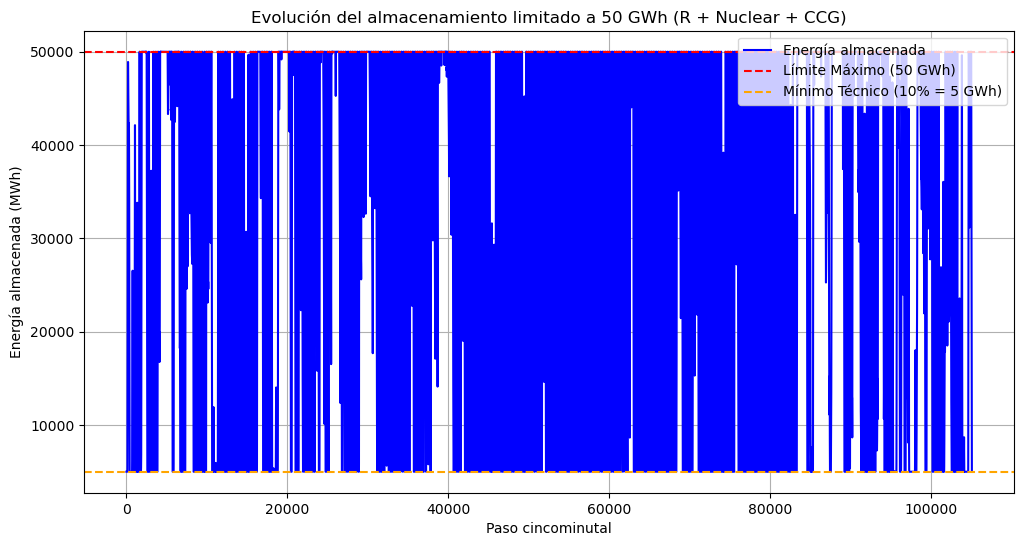

In [126]:
# 1. GRÁFICA DEL ALMACENAMIENTO (Evolución de la batería con límites)
plt.figure(figsize=(12, 6))

# Dibujamos la energía almacenada (dividida entre 12 para MWh)
plt.plot(esc_r_n_ccg_50["Almacenamiento_total"] / 12, label="Energía almacenada", color="blue")

# Líneas de referencia para los topes físicos
plt.axhline(50000, color="red", linestyle="--", label="Límite Máximo (50 GWh)")
plt.axhline(5000, color="orange", linestyle="--", label="Mínimo Técnico (10% = 5 GWh)")

plt.xlabel("Paso cincominutal")
plt.ylabel("Energía almacenada (MWh)")
plt.title("Evolución del almacenamiento limitado a 50 GWh (R + Nuclear + CCG)")
plt.legend(loc="upper right")
plt.grid(True)

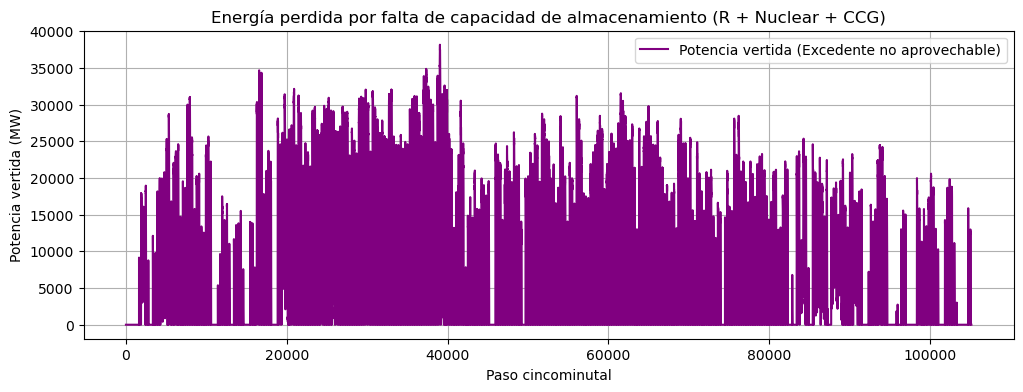

In [127]:
# 2. GRÁFICA DE LA ENERGÍA PERDIDA (Curtailment)
plt.figure(figsize=(12, 4)) 

# Dibujamos la columna de Vertido_ER (esta vez sin dividir por 12, porque queremos ver los picos de potencia en MW)
plt.plot(esc_r_n_ccg_50["Vertido_ER"], color="purple", label="Potencia vertida (Excedente no aprovechable)")

plt.xlabel("Paso cincominutal")
plt.ylabel("Potencia vertida (MW)")
plt.title("Energía perdida por falta de capacidad de almacenamiento (R + Nuclear + CCG)")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()